In [1]:
import matplotlib.pyplot as plt
import seaborn as sys
import numpy as np
import pandas as pd

In [2]:
from google.colab import files
uploaded=files.upload()

Saving int_online_tx.csv to int_online_tx (1).csv


In [3]:
df = pd.read_csv('int_online_tx.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataFrame Info:")
df.info()

print("\nMissing values in each column:")
display(df.isnull().sum())

First 5 rows of the dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/10 8:45,3.75,12583.0,France
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/10 8:45,3.75,12583.0,France
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,12/1/10 8:45,3.75,12583.0,France
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/10 8:45,0.85,12583.0,France
4,536370,21883,STARS GIFT TAPE,24,12/1/10 8:45,0.65,12583.0,France



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35116 entries, 0 to 35115
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    35116 non-null  int64  
 1   StockCode    35116 non-null  object 
 2   Description  35116 non-null  object 
 3   Quantity     35116 non-null  int64  
 4   InvoiceDate  35116 non-null  object 
 5   UnitPrice    35116 non-null  float64
 6   CustomerID   33698 non-null  float64
 7   Country      35116 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.1+ MB

Missing values in each column:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,1418
Country,0


In [4]:
# Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check for and remove duplicate rows
df.drop_duplicates(inplace=True)

print(f"DataFrame shape after cleaning: {df.shape}")
print("\nMissing values after cleaning:")
display(df.isnull().sum())

/tmp/ipykernel_10087/296215604.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


DataFrame shape after cleaning: (33634, 8)

Missing values after cleaning:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [5]:
# Calculate TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Descriptive statistics before handling negative values:")
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

# Filter out rows where Quantity or UnitPrice are less than or equal to 0
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("\nDescriptive statistics after handling negative values:")
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

print(f"DataFrame shape after handling negative values: {df.shape}")

Descriptive statistics before handling negative values:


,Quantity,UnitPrice,TotalPrice
count,33634.000000,33634.000000,33634.000000
mean,14.818339,4.483656,27.833218
std,31.716302,47.223934,69.208579
min,1.000000,0.040000,0.190000
25%,5.000000,1.250000,12.600000
50%,10.000000,1.950000,17.000000
75%,12.000000,3.750000,25.000000
max,2040.000000,4161.060000,4161.060000



Descriptive statistics after handling negative values:


,Quantity,UnitPrice,TotalPrice
count,33634.000000,33634.000000,33634.000000
mean,14.818339,4.483656,27.833218
std,31.716302,47.223934,69.208579
min,1.000000,0.040000,0.190000
25%,5.000000,1.250000,12.600000
50%,10.000000,1.950000,17.000000
75%,12.000000,3.750000,25.000000
max,2040.000000,4161.060000,4161.060000


DataFrame shape after handling negative values: (33634, 9)


In [6]:
# Calculate Recency, Frequency, Monetary (RFM) values

# Define a snapshot date for Recency calculation (one day after the last transaction in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'), # nunique counts unique invoices as purchases
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM DataFrame head:")
display(rfm_df.head())

print("\nDescriptive statistics of RFM features:")
display(rfm_df[['Recency', 'Frequency', 'Monetary']].describe())

RFM DataFrame head:


,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,4310.00
1,12348.0,75,4,1797.24
2,12349.0,19,1,1757.55
3,12350.0,310,1,334.40
4,12352.0,36,8,2506.04



Descriptive statistics of RFM features:


,Recency,Frequency,Monetary
count,414.000000,414.000000,414.000000
mean,96.405797,3.710145,2261.213647
std,104.638705,4.255524,3478.409822
min,1.000000,1.000000,51.560000
25%,19.000000,1.000000,457.050000
50%,53.000000,2.000000,1025.700000
75%,137.500000,4.000000,2659.962500
max,374.000000,32.000000,31906.820000


In [7]:
from sklearn.preprocessing import StandardScaler

# Apply log transformation to Recency, Frequency, and Monetary features
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].apply(np.log)

print("Descriptive statistics of RFM features after log transformation:")
display(rfm_log.describe())

# Scale the log-transformed RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert the scaled data back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

print("\nFirst 5 rows of the scaled RFM features:")
display(rfm_scaled_df.head())

print("\nDescriptive statistics of scaled RFM features:")
display(rfm_scaled_df.describe())

Descriptive statistics of RFM features after log transformation:


,Recency,Frequency,Monetary
count,414.000000,414.000000,414.000000
mean,3.817820,0.903770,6.988472
std,1.415242,0.848733,1.215291
min,0.000000,0.000000,3.942746
25%,2.944439,0.000000,6.124793
50%,3.970292,0.693147,6.933117
75%,4.923604,1.386294,7.886067
max,5.924256,3.465736,10.370575



First 5 rows of the scaled RFM features:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,-2.210543,1.229363,1.137087
1,0.353489,0.569211,0.416482
2,-0.617872,-1.066134,0.398084
3,1.357417,-1.066134,-0.968951
4,-0.165756,1.386883,0.690370



Descriptive statistics of scaled RFM features:


,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
count,4.140000e+02,4.140000e+02,4.140000e+02
mean,6.436076e-17,-7.294219e-17,6.736426e-16
std,1.001210e+00,1.001210e+00,1.001210e+00
min,-2.700909e+00,-1.066134e+00,-2.509203e+00
25%,-6.178717e-01,-1.066134e+00,-7.115374e-01
50%,1.078657e-01,-2.484619e-01,-4.560393e-02
75%,7.822842e-01,5.692106e-01,7.394779e-01
max,1.490193e+00,3.022228e+00,2.786325e+00


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1

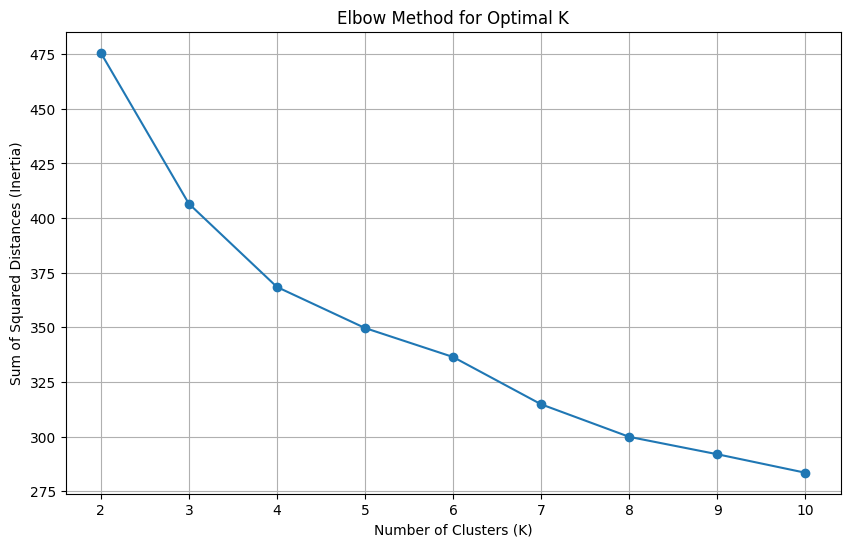

Based on the Elbow Method, the optimal number of clusters can be determined from the plot above. Look for the 'elbow' point where the rate of decrease in SSD sharply changes.


In [8]:
!pip uninstall -y numpy
!pip install numpy==1.26.4 # Downgrade numpy to a version compatible with scikit-learn-extra
!pip install --upgrade scikit-learn-extra # Reinstall scikit-learn-extra to ensure compatibility
from sklearn_extra.cluster import KMedoids

# Determine optimal number of clusters using the Elbow Method
ssd = [] # Sum of Squared Distances
range_n_clusters = range(2, 11)

for num_clusters in range_n_clusters:
    kmedoids = KMedoids(n_clusters=num_clusters, random_state=42)
    kmedoids.fit(rfm_scaled_df)
    ssd.append(kmedoids.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, ssd, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

print("Based on the Elbow Method, the optimal number of clusters can be determined from the plot above. Look for the 'elbow' point where the rate of decrease in SSD sharply changes.")